# SnapBudget - Head 1 Full: Generate Dataset + Training BiLSTM + Donut + Pipeline
**Coding Camp 2026 - DBS Foundation - CC26-PSU098**

Notebook lengkap dan bersih mencakup:
- **Bagian A**: Generate dataset sintetis Head 1C (9.600 sampel)
- **Bagian B**: Training BiLSTM Head 1C dengan GradientTape
- **Bagian C**: Load Donut fine-tuned dari Google Drive
- **Bagian D**: Helper functions (parser v6)
- **Bagian E**: Pipeline end-to-end + test + visualisasi

Alur pipeline:
```
Foto Struk -> [Donut] -> [Parser v6] -> [BiLSTM Head 1C] -> JSON Output API
```


## Cell 1 - Install

In [1]:
!pip install transformers datasets sentencepiece torch torchvision -q
!pip install tensorflow scikit-learn matplotlib Pillow numpy -q
print("Instalasi selesai.")


Instalasi selesai.


## Cell 2 - Import & Konfigurasi

In [2]:
import os, re, json, time, warnings, pickle, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image as PILImage

import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42); random.seed(42)

DEVICE_TORCH = "cuda" if torch.cuda.is_available() else "cpu"
tf.config.set_visible_devices([], 'GPU')

print(f"PyTorch : {torch.__version__} | device={DEVICE_TORCH}")
print(f"TF      : {tf.__version__}")

CATEGORIES = ['makanan','minuman','transportasi','belanja',
               'tagihan','hiburan','kesehatan','lain_lain']
N_CATS = len(CATEGORIES)
CAT_ID = {cat: i for i, cat in enumerate(CATEGORIES)}

CAT_COLORS = {
    'makanan':'#1D9E75','minuman':'#378ADD',
    'transportasi':'#BA7517','belanja':'#7F77DD',
    'tagihan':'#A32D2D','hiburan':'#D4537E',
    'kesehatan':'#1ABC9C','lain_lain':'#888780',
}

DRIVE_DIR = "/content/drive/MyDrive/LaporKeuangan"
MAX_LEN   = 30

print(f"Kategori ({N_CATS}): {CATEGORIES}")


PyTorch : 2.10.0+cu128 | device=cuda
TF      : 2.19.0
Kategori (8): ['makanan', 'minuman', 'transportasi', 'belanja', 'tagihan', 'hiburan', 'kesehatan', 'lain_lain']


---
## BAGIAN A - Generate Dataset Sintetis Head 1C

## Cell 3 - Keyword Rules per Kategori

In [3]:
KEYWORD_RULES = {
    'makanan': [
        "Nasi Goreng","Nasi Putih","Nasi Uduk","Nasi Kuning","Nasi Padang",
        "Nasi Ayam","Nasi Bebek","Nasi Bakar","Nasi Box","Nasi Campur",
        "Nasi Pecel","Nasi Liwet","Nasi Goreng Seafood","Nasi Goreng Spesial",
        "Nasi Goreng Kampung","Nasi Ayam Geprek","Nasi Ayam Kremes",
        "Ayam Goreng","Ayam Bakar","Ayam Geprek","Ayam Kremes","Ayam Penyet",
        "Bebek Goreng","Ikan Goreng","Ikan Bakar","Tempe Goreng","Tahu Goreng",
        "Telur Dadar","Telur Ceplok","Sate Ayam","Sate Kambing","Bakso",
        "Mie Goreng","Mie Ayam","Kwetiau","Bihun Goreng","Cap Cay",
        "Gorengan","Pisang Goreng","Cireng","Batagor","Siomay","Pempek",
        "Lumpia","Risol","Martabak","Roti Bakar","Sandwich","Burger",
        "Pizza","Pasta","Kebab","Hotdog","Nugget","Dimsum",
        "Paket Nasi Ayam","Paket Hemat","Makan Siang","Makan Malam","Sarapan",
        "BBQ Chicken","Chicken Wing","Steak","Grill","Tongseng","Gulai",
        "Rawon","Soto","Gado-Gado","Ketoprak","Lontong","Kupat Tahu",
        "Pecel Lele","Nasi Warteg","Tahu Tempe","Tahu Ikan Oma Giok",
        "Egg Tart", "Pizza Toast", "Ganache", "Croissant", "Muffin",
        "Waffle", "Pancake", "French Toast", "Donut", "Brownie",
        "Cheesecake", "Tiramisu", "Pudding", "Cookie", "Biscuit",
        "Sausage Bread", "Banana Bread", "Garlic Bread", "Toast",
        "Sandwich", "Club Sandwich", "BLT", "Wrap",
        "Tteokbokki", "Ramyeon", "Bibimbap", "Kimbap", "Japchae",
        "Bulgogi", "Galbi", "Dakgalbi", "Jjajangmyeon",
        "Pasta", "Spaghetti", "Lasagna", "Risotto", "Gnocchi",
        "Ramen", "Udon", "Soba", "Takoyaki", "Tempura",
        "Salad", "Caesar Salad", "Greek Salad",
        "Soup", "Mushroom Soup", "Tomato Soup",
        "Rice Bowl", "Chicken Bowl", "Beef Bowl",
        "Fried Rice", "Noodle", "Fried Noodle",
        "Spring Roll", "Dumpling", "Wonton",
        "Ice Cream", "Gelato", "Sorbet", "Parfait",
        "Crepe", "Macaron", "Eclair", "Profiterole",
        "Chocolate Cake", "Red Velvet", "Carrot Cake",
        "Tart", "Pie", "Strudel",
        "Nachos", "Chips", "Popcorn", "Pretzel",
        "Bruschetta", "Crostini", "Carpaccio",
        "Chicken Wing", "Buffalo Wing", "Nugget",
        "Onion Ring", "Mozzarella Stick", "Fries",
    ],
    'minuman': [
        "Kopi Susu","Kopi Hitam","Kopi Americano","Kopi Latte","Kopi Cappuccino",
        "Kopi Espresso","Kopi Mocha","Kopi Dalgona","Kopi Tubruk","Kopi Instan",
        "Es Kopi Susu","Cold Brew","Iced Latte","Iced Americano",
        "Kopi Gula Aren","Kopi Aren","Es Teh","Teh Manis","Teh Tarik",
        "Teh Susu","Milk Tea","Boba","Bubble Tea","Thai Tea",
        "Matcha Latte","Es Matcha","Teh Hijau","Jus Alpukat","Jus Mangga",
        "Jus Jeruk","Jus Jambu","Jus Semangka","Jus Melon","Smoothie",
        "Milkshake","Es Buah","Es Campur","Es Dawet","Es Cendol",
        "Es Kelapa Muda","Air Kelapa","Aqua","Le Mineral","Air Mineral",
        "Teh Botol","Pocari Sweat","Mizone","Good Day","Nescafe","Energen",
        "Ovaltine","Caramel Macchiato","Frappe","Vanilla Latte",
        "Hazelnut Latte","Brown Sugar Latte","Kopi Susu Kolonel",
        "Latte", "Cappuccino", "Americano", "Espresso",
        "Macchiato", "Mocha", "Frappe", "Cold Brew",
        "Matcha", "Hojicha", "Oolong Tea", "Earl Grey",
        "Chamomile", "Peppermint Tea", "Lemon Tea",
        "Lemonade", "Pink Lemonade", "Lychee Drink",
        "Mango Drink", "Strawberry Drink", "Peach Tea",
        "Caramel Latte", "Vanilla Latte", "Hazelnut Latte",
        "Brown Sugar", "Taro Latte", "Lavender Latte",
        "Club Soda", "Sparkling Water", "Mineral Water",
        "Orange Juice", "Apple Juice", "Grape Juice",
        "Yakult", "Calpico", "Ramune",
    ],
    'transportasi': [
        "GrabBike","GoRide","MaximBike","OjekOnline","Ojek",
        "GrabCar","GoCar","MaximCar","Taksi Online","Mobil Online",
        "KRL","Commuter Line","MRT","LRT","Transjakarta",
        "Bus","Angkot","Mikrolet","Metromini","Damri","Busway",
        "Tiket KRL","Tiket MRT","Tiket Bus","Tiket Kereta",
        "Parkir Motor","Parkir Mobil","Parkir","Retribusi Parkir",
        "Bensin","BBM","Pertamax","Pertalite","Isi Bensin","SPBU",
        "Ganti Oli","Servis Motor","Grab","Gojek","Maxim",
        "Tiket Pesawat","Kereta Api","Tol","E-Toll",
    ],
    'belanja': [
        "Baju","Kaos","Kemeja","Celana","Rok","Dress",
        "Jaket","Hoodie","Sweater","Cardigan","Blazer",
        "Sepatu","Sandal","Tas","Dompet","Ikat Pinggang",
        "Topi","Kacamata","Jam Tangan","Gelang",
        "Buku Tulis","Buku Catatan","Pulpen","Pensil",
        "Spidol","Stabilo","Penggaris","Kertas HVS",
        "Map Plastik","Folder","Buku Kuliah","Textbook","Modul",
        "Charger","Kabel Data","Earphone","Headset",
        "Power Bank","Mouse","Keyboard","Flashdisk","Lampu","Baterai",
        "Sabun","Sampo","Pasta Gigi","Sikat Gigi",
        "Detergen","Softener","Tisu","Pembalut","Deodoran",
        "Skincare","Sunscreen","Belanja Online","Shopee","Tokopedia",
    ],
    'tagihan': [
        "Token Listrik","Bayar Listrik","PLN","Tagihan Listrik",
        "PDAM","Air PAM","Tagihan Air",
        "Pulsa","Kuota Internet","Data Internet","Paket Data","Isi Pulsa",
        "WiFi","Tagihan WiFi","Internet Bulanan","IndiHome","First Media",
        "Netflix","Spotify","YouTube Premium","Disney Plus",
        "Apple Music","Canva Pro","Adobe","Microsoft 365",
        "Tagihan Telepon","Tagihan HP","Bayar Kos","Sewa Kos",
        "Kontrakan","Uang Kos","Biaya Kos","BPJS Kesehatan","Asuransi",
        "Iuran","Biaya Admin","Administrasi",
    ],
    'hiburan': [
        "Bioskop","XXI","CGV","Cinepolis","Tiket Bioskop","Nonton Film",
        "Top Up Game","Top Up Mobile Legends","Top Up PUBG","Top Up FF",
        "Top Up Genshin","Diamond ML","UC PUBG","Voucher Game","Steam",
        "Karaoke","Bowling","Billiard","Gym","Fitness",
        "Kolam Renang","Futsal","Badminton","Tenis","Tiket Konser",
        "Tiket Event","Festival","Pameran","Tiket Wisata","Tiket Masuk",
        "Wahana","Taman Bermain","Kebun Binatang",
        "Buku Novel","Komik","Cat Akrilik","Alat Musik",
    ],
    'kesehatan': [
        "Paracetamol","Ibuprofen","Amoxicillin","Antasida",
        "Vitamin C","Vitamin D","Multivitamin","Suplemen",
        "Obat Batuk","Obat Flu","Obat Sakit Kepala","Obat Maag",
        "Obat Diare","Masker","Hansaplast","Betadine","Minyak Kayu Putih",
        "Dokter","Klinik","Puskesmas","Rumah Sakit",
        "Konsultasi Dokter","Biaya Periksa","Biaya Berobat",
        "Resep Dokter","Apotek","Kimia Farma","Guardian",
        "Dokter Gigi","Tambal Gigi","Cabut Gigi",
        "Rapid Test","PCR","Cek Darah","Lab Kesehatan",
        "Kacamata","Lensa Kontak","Softlens",
    ],
    'lain_lain': [
        "Fotokopi","Print","Scan","Jilid","Materai","Stempel","Legalisir",
        "Biaya Pendaftaran","Formulir",
        "Ongkir","Ongkos Kirim","JNE","JNT","SiCepat","Anteraja",
        "GoSend","GrabExpress",
        "Donasi","Infaq","Sedekah","Zakat",
        "Iuran Kelas","Iuran Organisasi","Patungan",
        "Laundry","Cuci Baju","Setrika",
        "Potong Rambut","Cukur","Salon",
        "ATM","Transfer","Biaya Transfer","Jajan","Lain-lain",
    ],
}

print("Keyword rules per kategori:")
for cat, items in KEYWORD_RULES.items():
    print(f"  {cat:<15}: {len(items):3d} kata kunci")
print(f"Total: {sum(len(v) for v in KEYWORD_RULES.values())} kata kunci")


Keyword rules per kategori:
  makanan        :  76 kata kunci
  minuman        :  57 kata kunci
  transportasi   :  44 kata kunci
  belanja        :  57 kata kunci
  tagihan        :  37 kata kunci
  hiburan        :  37 kata kunci
  kesehatan      :  38 kata kunci
  lain_lain      :  35 kata kunci
Total: 381 kata kunci


## Cell 4 - Generate Dataset (9.600 sampel)

In [4]:
def augment_item_name(text, rng):
    op = rng.randint(0, 5)
    if op == 0: return text.lower()
    elif op == 1: return text.upper()
    elif op == 2:
        qty = rng.choice(["1x","2x","3x","1 ","2 "])
        return f"{qty}{text}"
    elif op == 3:
        words = text.split()
        if len(words) > 1:
            idx = rng.randint(0, len(words))
            words[idx] = words[idx][:max(3, len(words[idx])-1)]
            return " ".join(words)
        return text
    return text


def generate_dataset(keyword_rules, n_per_category=1200, augment_ratio=0.4, seed=42):
    rng = np.random.RandomState(seed)
    texts, labels = [], []
    for cat, keywords in keyword_rules.items():
        cat_id = CAT_ID[cat]
        n_aug  = int(n_per_category * augment_ratio)
        n_ori  = n_per_category - n_aug
        samples = (
            [keywords[rng.randint(0, len(keywords))] for _ in range(n_ori)] +
            [augment_item_name(keywords[rng.randint(0, len(keywords))], rng) for _ in range(n_aug)]
        )
        rng.shuffle(samples)
        texts.extend(samples)
        labels.extend([cat_id] * len(samples))
    idx = list(range(len(texts)))
    rng.shuffle(idx)
    return [texts[i] for i in idx], [labels[i] for i in idx]


print("Generating dataset sintetis...")
texts, labels = generate_dataset(KEYWORD_RULES, n_per_category=1200, augment_ratio=0.4)
print(f"Total sampel: {len(texts):,}")
print("\nDistribusi:")
lc = Counter(labels)
for i, cat in enumerate(CATEGORIES):
    print(f"  {cat:<15}: {lc[i]:4d}")
print("\nContoh sampel:")
for i in range(0, 16, 2):
    print(f"  [{CATEGORIES[labels[i]]:<15}] {texts[i]}")


Generating dataset sintetis...
Total sampel: 9,600

Distribusi:
  makanan        : 1200
  minuman        : 1200
  transportasi   : 1200
  belanja        : 1200
  tagihan        : 1200
  hiburan        : 1200
  kesehatan      : 1200
  lain_lain      : 1200

Contoh sampel:
  [makanan        ] bakso
  [belanja        ] Skincare
  [lain_lain      ] Transfer
  [transportasi   ] Metromini
  [belanja        ] Pulpen
  [kesehatan      ] Guardian
  [transportasi   ] Bensin
  [belanja        ] Kemeja


## Cell 5 - Tokenizer & Preprocessing

In [5]:
def build_vocab(texts, min_freq=1):
    char_count = Counter()
    for text in texts:
        char_count.update(text.lower())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for char, cnt in char_count.items():
        if cnt >= min_freq:
            vocab[char] = len(vocab)
    return vocab


def tokenize(text, vocab, max_len=30):
    PAD_ID, UNK_ID = vocab['<PAD>'], vocab['<UNK>']
    ids = [vocab.get(c, UNK_ID) for c in text.lower().strip()]
    if len(ids) >= max_len: return ids[:max_len]
    return ids + [PAD_ID] * (max_len - len(ids))


vocab     = build_vocab(texts)
VOCAB_SIZE = len(vocab)

X_raw = np.array([tokenize(t, vocab, MAX_LEN) for t in texts], dtype=np.int32)
y_raw = np.array(labels, dtype=np.int32)
y_oh  = tf.keras.utils.to_categorical(y_raw, N_CATS).astype(np.float32)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_raw, y_oh, test_size=0.30, random_state=42, stratify=y_raw)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42,
    stratify=np.argmax(y_tmp, axis=1))

print(f"Vocab size : {VOCAB_SIZE}")
print(f"Split dataset:")
print(f"  Train : {X_tr.shape[0]:,}")
print(f"  Val   : {X_val.shape[0]:,}")
print(f"  Test  : {X_test.shape[0]:,}")


Vocab size : 35
Split dataset:
  Train : 6,720
  Val   : 1,440
  Test  : 1,440


---
## BAGIAN B - Training BiLSTM Head 1C

## Cell 6 - Arsitektur Model

In [6]:
class FocalLossSmooth(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma; self.smoothing = smoothing

    def call(self, y_true, y_pred):
        n  = tf.cast(tf.shape(y_true)[-1], tf.float32)
        ys = (1 - self.smoothing) * y_true + self.smoothing / n
        yp = tf.clip_by_value(y_pred, 1e-8, 1.0)
        ce = -ys * tf.math.log(yp)
        w  = tf.pow(1.0 - yp, self.gamma)
        return tf.reduce_mean(tf.reduce_sum(w * ce, axis=-1))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'smoothing': self.smoothing})
        return cfg


class AttentionLayer(layers.Layer):
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, activation='tanh')
        self.V = layers.Dense(1)
        self.units = units

    def call(self, encoder_output):
        score   = self.V(self.W(encoder_output))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * encoder_output, axis=1)
        return context, weights

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units})
        return cfg


class ItemClassifierModel(Model):
    def __init__(self, vocab_size, embed_dim=64, lstm_units=128,
                 n_classes=8, dropout=0.3, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size; self.embed_dim = embed_dim
        self.lstm_units = lstm_units; self.n_classes = n_classes
        self.dropout_rate = dropout

        self.embedding    = layers.Embedding(vocab_size, embed_dim, mask_zero=True)
        self.bilstm1      = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=True, dropout=dropout))
        self.bilstm2      = layers.Bidirectional(
            layers.LSTM(lstm_units//2, return_sequences=True, dropout=dropout))
        self.attention    = AttentionLayer(units=lstm_units)
        self.proj         = layers.Dense(lstm_units * 2)
        self.dense1       = layers.Dense(256, activation='gelu')
        self.dense2       = layers.Dense(128, activation='gelu')
        self.drop1        = layers.Dropout(dropout)
        self.drop2        = layers.Dropout(dropout * 0.5)
        self.bn1          = layers.BatchNormalization()
        self.bn2          = layers.BatchNormalization()
        self.output_layer = layers.Dense(n_classes, activation='softmax')

    def call(self, x, training=False):
        emb    = self.embedding(x)
        out1   = self.bilstm1(emb, training=training)
        out2   = self.bilstm2(out1, training=training)
        ctx, _ = self.attention(out2)
        res    = self.proj(ctx)
        h      = self.dense1(res)
        h      = self.drop1(h, training=training)
        h      = self.bn1(h, training=training)
        h      = self.dense2(h + res[:, :h.shape[-1]])
        h      = self.drop2(h, training=training)
        h      = self.bn2(h, training=training)
        return self.output_layer(h)

    def get_config(self):
        return {'vocab_size':self.vocab_size,'embed_dim':self.embed_dim,
                'lstm_units':self.lstm_units,'n_classes':self.n_classes,
                'dropout':self.dropout_rate}


model_1c = ItemClassifierModel(VOCAB_SIZE, 64, 128, N_CATS, 0.3, name="BiLSTM_Head1C")
_ = model_1c(tf.zeros((1, MAX_LEN), dtype=tf.int32))
n_params = sum(tf.size(v).numpy() for v in model_1c.trainable_variables)
print(f"Model BiLSTM Head 1C siap! | Params: {n_params:,}")
print("Arsitektur: Embedding -> BiLSTM(128) -> BiLSTM(64) -> Attention -> Dense(256+128) -> Softmax(8)")


Model BiLSTM Head 1C siap! | Params: 514,377
Arsitektur: Embedding -> BiLSTM(128) -> BiLSTM(64) -> Attention -> Dense(256+128) -> Softmax(8)


## Cell 7 - Training Loop (GradientTape)

TRAINING Head 1C - BiLSTM Classifier
  Epochs=30 | Batch=128 | LR=0.002 | Patience=7
------------------------------------------------------------
Epoch  1/30 | loss=1.5131 val=1.5901 | acc=0.244 val_acc=0.125 | f1=0.242 val_f1=0.028 | 43.6s
  -> Best val_f1=0.0279
Epoch  2/30 | loss=1.3371 val=1.5880 | acc=0.370 val_acc=0.125 | f1=0.370 val_f1=0.028 | 15.4s
Epoch  3/30 | loss=1.1960 val=1.3952 | acc=0.436 val_acc=0.308 | f1=0.437 val_f1=0.265 | 21.4s
  -> Best val_f1=0.2651
Epoch  4/30 | loss=0.9698 val=0.9046 | acc=0.549 val_acc=0.570 | f1=0.550 val_f1=0.584 | 14.9s
  -> Best val_f1=0.5838
Epoch  5/30 | loss=0.7294 val=0.5546 | acc=0.703 val_acc=0.831 | f1=0.704 val_f1=0.831 | 14.9s
  -> Best val_f1=0.8311
Epoch  6/30 | loss=0.5718 val=0.4706 | acc=0.826 val_acc=0.922 | f1=0.826 val_f1=0.922 | 15.3s
  -> Best val_f1=0.9221
Epoch  7/30 | loss=0.4807 val=0.4123 | acc=0.894 val_acc=0.965 | f1=0.894 val_f1=0.965 | 16.5s
  -> Best val_f1=0.9646
Epoch  8/30 | loss=0.4249 val=0.3483 | acc=0.

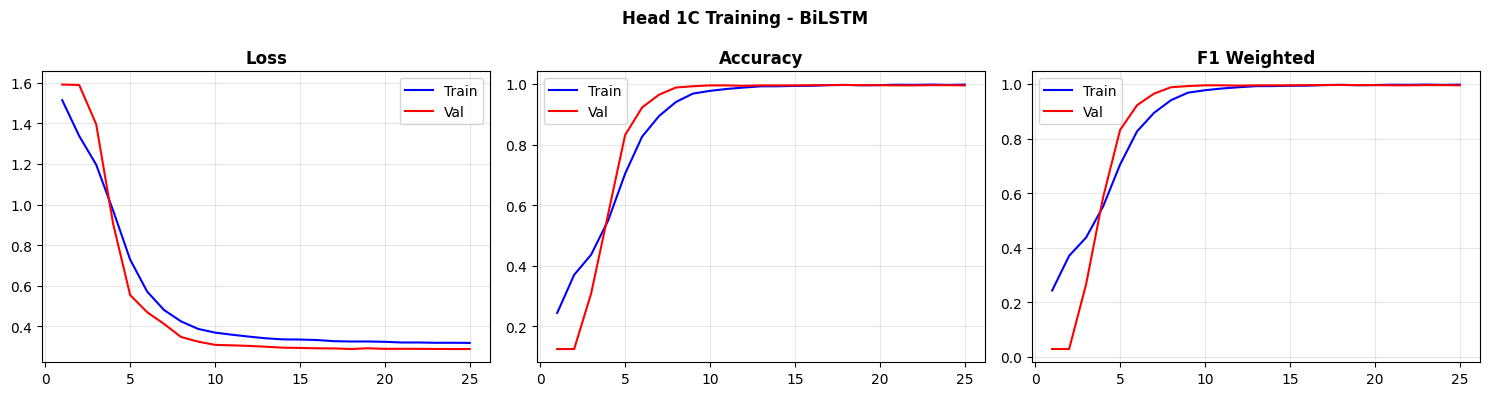

In [7]:
EPOCHS=30; BATCH_SIZE=128; LR_INIT=2e-3; LR_MIN=1e-5; PATIENCE=7; GRAD_CLIP=1.0

class WarmupCosineSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, lr_init, warmup_steps, total_steps, lr_min=1e-5):
        super().__init__()
        self.lr_init=lr_init; self.warmup_steps=float(warmup_steps)
        self.total_steps=float(total_steps); self.lr_min=lr_min

    def __call__(self, step):
        s  = tf.cast(step, tf.float32)
        wu = s / self.warmup_steps * self.lr_init
        co = self.lr_min + 0.5*(self.lr_init-self.lr_min)*(
            1+tf.math.cos(np.pi*(s-self.warmup_steps)/(self.total_steps-self.warmup_steps)))
        return tf.where(s < self.warmup_steps, wu, co)

    def get_config(self):
        return {'lr_init':self.lr_init,'warmup_steps':self.warmup_steps,
                'total_steps':self.total_steps,'lr_min':self.lr_min}


total_steps  = (len(X_tr) // BATCH_SIZE) * EPOCHS
warmup_steps = total_steps // 10
optimizer    = tf.keras.optimizers.Adam(
    learning_rate=WarmupCosineSchedule(LR_INIT, warmup_steps, total_steps, LR_MIN))
loss_fn      = FocalLossSmooth(gamma=2.0, smoothing=0.1)

train_ds = (tf.data.Dataset.from_tensor_slices((
    tf.constant(X_tr,  dtype=tf.int32),
    tf.constant(y_tr,  dtype=tf.float32)))
    .shuffle(len(X_tr), seed=42).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((
    tf.constant(X_val, dtype=tf.int32),
    tf.constant(y_val, dtype=tf.float32)))
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))


@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        pred  = model_1c(x, training=True)
        loss  = loss_fn(y, pred)
        l2    = tf.add_n([tf.nn.l2_loss(v) for v in model_1c.trainable_variables
                          if 'kernel' in v.name]) * 1e-5
        total = loss + l2
    grads = tape.gradient(total, model_1c.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, GRAD_CLIP)
    optimizer.apply_gradients(zip(grads, model_1c.trainable_variables))
    return total, pred


@tf.function
def val_step(x, y):
    pred = model_1c(x, training=False)
    return loss_fn(y, pred), pred


print("="*60)
print("TRAINING Head 1C - BiLSTM Classifier")
print("="*60)
print(f"  Epochs={EPOCHS} | Batch={BATCH_SIZE} | LR={LR_INIT} | Patience={PATIENCE}")
print("-"*60)

history = {k:[] for k in ['train_loss','val_loss','train_f1','val_f1','train_acc','val_acc']}
best_val_f1 = 0.0; best_weights = None; patience_count = 0

from sklearn.metrics import f1_score, accuracy_score

for epoch in range(EPOCHS):
    t0 = time.time()
    tr_losses, tr_pred, tr_true = [], [], []
    for xb, yb in train_ds:
        loss, pred = train_step(xb, yb)
        tr_losses.append(loss.numpy())
        tr_pred.extend(tf.argmax(pred, axis=1).numpy())
        tr_true.extend(tf.argmax(yb, axis=1).numpy())

    vl_losses, vl_pred, vl_true = [], [], []
    for xb, yb in val_ds:
        loss, pred = val_step(xb, yb)
        vl_losses.append(loss.numpy())
        vl_pred.extend(tf.argmax(pred, axis=1).numpy())
        vl_true.extend(tf.argmax(yb, axis=1).numpy())

    tr_loss = np.mean(tr_losses); vl_loss = np.mean(vl_losses)
    tr_f1  = f1_score(tr_true, tr_pred, average='weighted', zero_division=0)
    vl_f1  = f1_score(vl_true, vl_pred, average='weighted', zero_division=0)
    tr_acc = accuracy_score(tr_true, tr_pred)
    vl_acc = accuracy_score(vl_true, vl_pred)

    for k, v in zip(['train_loss','val_loss','train_f1','val_f1','train_acc','val_acc'],
                    [tr_loss,vl_loss,tr_f1,vl_f1,tr_acc,vl_acc]):
        history[k].append(v)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | loss={tr_loss:.4f} val={vl_loss:.4f} | "
          f"acc={tr_acc:.3f} val_acc={vl_acc:.3f} | f1={tr_f1:.3f} val_f1={vl_f1:.3f} | "
          f"{time.time()-t0:.1f}s")

    if vl_f1 > best_val_f1:
        best_val_f1  = vl_f1
        best_weights = [v.numpy() for v in model_1c.trainable_variables]
        patience_count = 0
        print(f"  -> Best val_f1={best_val_f1:.4f}")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"  Early stopping epoch {epoch+1}")
            break

if best_weights:
    for v, w in zip(model_1c.trainable_variables, best_weights): v.assign(w)

print(f"\nTraining selesai! Best val_f1={best_val_f1:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history['train_loss'])+1)
for ax, key, title in zip(axes, ['loss','acc','f1'], ['Loss','Accuracy','F1 Weighted']):
    ax.plot(ep, history[f'train_{key}'], 'b-', label='Train')
    ax.plot(ep, history[f'val_{key}'],   'r-', label='Val')
    ax.set_title(title, fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Head 1C Training - BiLSTM', fontweight='bold')
plt.tight_layout()
plt.savefig('head1c_training.png', dpi=100, bbox_inches='tight')
plt.show()


## Cell 8 - Evaluasi Head 1C

EVALUASI HEAD 1C - Test Set
              precision    recall  f1-score   support

     makanan      1.000     0.994     0.997       180
     minuman      0.994     1.000     0.997       180
transportasi      1.000     1.000     1.000       180
     belanja      1.000     0.978     0.989       180
     tagihan      1.000     1.000     1.000       180
     hiburan      1.000     1.000     1.000       180
   kesehatan      0.978     1.000     0.989       180
   lain_lain      1.000     1.000     1.000       180

    accuracy                          0.997      1440
   macro avg      0.997     0.997     0.997      1440
weighted avg      0.997     0.997     0.997      1440

Overall Accuracy : 0.9965
Overall F1       : 0.9965


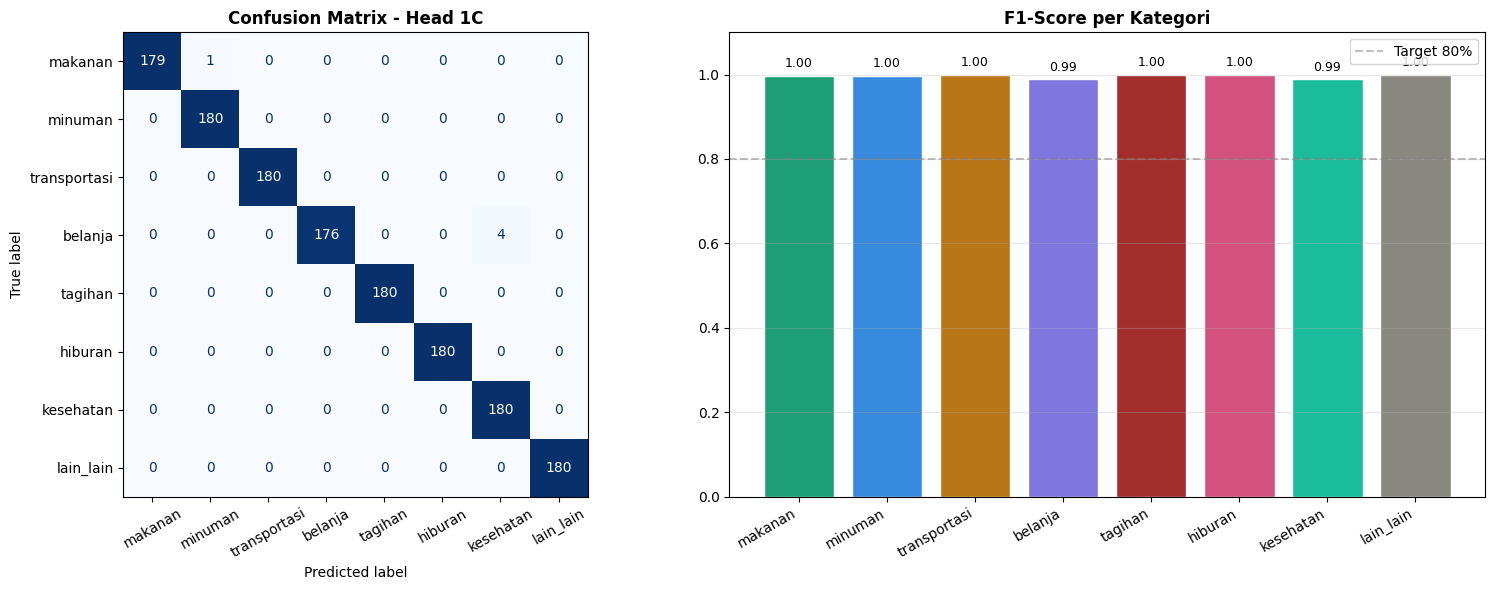


Test manual:
Item                         Prediksi           Conf
------------------------------------------------------
Nasi Ayam Geprek             makanan           69.1%
Kopi Susu Kolonel            minuman           67.6%
GrabBike                     transportasi      72.2%
Baju Polos                   belanja           59.9%
Token Listrik                tagihan           71.3%
Bioskop XXI                  transportasi      62.0%
Paracetamol                  kesehatan         69.7%
Fotokopi                     lain_lain         71.2%


In [8]:
test_ds = (tf.data.Dataset.from_tensor_slices((
    tf.constant(X_test, dtype=tf.int32),
    tf.constant(y_test, dtype=tf.float32)))
    .batch(256))

all_pred, all_true = [], []
for xb, yb in test_ds:
    pred = model_1c(xb, training=False)
    all_pred.extend(tf.argmax(pred, axis=1).numpy())
    all_true.extend(tf.argmax(yb, axis=1).numpy())

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print("="*65); print("EVALUASI HEAD 1C - Test Set"); print("="*65)
print(classification_report(all_true, all_pred, target_names=CATEGORIES, digits=3))

print(f"Overall Accuracy : {accuracy_score(all_true, all_pred):.4f}")
print(f"Overall F1       : {f1_score(all_true, all_pred, average='weighted', zero_division=0):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay(confusion_matrix(all_true, all_pred),
    display_labels=CATEGORIES).plot(ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=30)
axes[0].set_title('Confusion Matrix - Head 1C', fontweight='bold')

f1_per = f1_score(all_true, all_pred, average=None, zero_division=0)
colors = [CAT_COLORS[c] for c in CATEGORIES]
bars   = axes[1].bar(CATEGORIES, f1_per, color=colors, edgecolor='white')
axes[1].set_title('F1-Score per Kategori', fontweight='bold')
axes[1].set_xticklabels(CATEGORIES, rotation=30, ha='right')
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Target 80%')
axes[1].legend()
for bar, f1 in zip(bars, f1_per):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{f1:.2f}', ha='center', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('head1c_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nTest manual:")
test_items = ["Nasi Ayam Geprek","Kopi Susu Kolonel","GrabBike",
              "Baju Polos","Token Listrik","Bioskop XXI","Paracetamol","Fotokopi"]
print(f"{'Item':<28} {'Prediksi':<16} {'Conf':>6}")
print("-"*54)
for item in test_items:
    x    = tf.constant([tokenize(item, vocab, MAX_LEN)], dtype=tf.int32)
    probs= model_1c(x, training=False).numpy()[0]
    idx  = int(np.argmax(probs))
    print(f"{item:<28} {CATEGORIES[idx]:<16} {probs[idx]*100:>5.1f}%")


## Cell 9 - Simpan Head 1C ke Google Drive

In [17]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(DRIVE_DIR, exist_ok=True)
model_1c.save_weights(f"{DRIVE_DIR}/head1c_v2.weights.h5")
print(f"Weights: {DRIVE_DIR}/head1c_v2.weights.h5")

with open(f"{DRIVE_DIR}/head1c_v2_vocab.pkl", 'wb') as f:
    pickle.dump(vocab, f)
print(f"Vocab  : {DRIVE_DIR}/head1c_v2_vocab.pkl")

config = {
    'vocab_size':VOCAB_SIZE,'embed_dim':64,'lstm_units':128,
    'n_classes':N_CATS,'dropout':0.3,'max_len':MAX_LEN,
    'categories':CATEGORIES,'best_val_f1':float(best_val_f1),'version':'v2',
}
with open(f"{DRIVE_DIR}/head1c_v2_config.json", 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print(f"Config : {DRIVE_DIR}/head1c_v2_config.json")
print(f"\nSemua tersimpan! Best val_f1={best_val_f1:.4f}")

ValueError: Mountpoint must not already contain files

---
## BAGIAN C - Load Donut Fine-tuned

## Cell 10 - Load Donut dari Google Drive

In [19]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DONUT_DIR  = "/content/drive/MyDrive/LaporKeuangan/donut_finetuned_cord_v2"
print("Loading Donut fine-tuned...")
processor_ft = DonutProcessor.from_pretrained(DONUT_DIR, use_fast=False)
model_donut  = VisionEncoderDecoderModel.from_pretrained(DONUT_DIR)
model_donut  = model_donut.to(DEVICE_TORCH)
model_donut.eval()
print(f"Donut loaded: {DONUT_DIR} | device={DEVICE_TORCH}")

Mounted at /content/drive
Loading Donut fine-tuned...


Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

Donut loaded: /content/drive/MyDrive/LaporKeuangan/donut_finetuned_cord_v2 | device=cuda


---
## BAGIAN D - Helper Functions Parser

## Cell 11 - parse_price_text, safe_parse_json, parse_donut_output v6

In [20]:
def parse_price_text(text):
    if not text: return 0
    clean = str(text).upper().replace('RP','').strip()
    clean = re.sub(r'O{2,}', lambda m: '0'*len(m.group()), clean)
    clean = re.sub(r'(?<=\d)O(?=\d)', '0', clean)
    if re.search(r'\d\.\d{3},\d{2}$', clean):
        clean = clean.replace('.','').split(',')[0]
    else:
        clean = re.sub(r'\.(?=\d{3}(?:\D|$))','',clean)
        clean = clean.replace(',','')
    digits = re.sub(r'[^0-9]','',clean)
    return int(digits) if digits else 0


def safe_parse_json(text):
    raw = re.sub(r'^<s_cord-v2>\s*', '', text).strip()
    try: return json.loads(raw)
    except: pass
    for i in range(len(raw), 0, -1):
        if raw[i-1] == '}':
            try: return json.loads(raw[:i])
            except: continue
    repaired = re.sub(r',\s*"[^"]+"\s*:\s*"[^"]*$', '', raw)
    repaired = re.sub(r',\s*"[^"]+"\s*:\s*$', '', repaired)
    open_b = repaired.count('[') - repaired.count(']')
    open_c = repaired.count('{') - repaired.count('}')
    repaired += ']' * max(0, open_b) + '}' * max(0, open_c)
    try: return json.loads(repaired)
    except: pass
    items   = re.findall(r'"nm"\s*:\s*"([^"]+)"[^}]*?"price"\s*:\s*"([^"]+)"', raw)
    total_m = re.search(r'"total_price"\s*:\s*"([\d.,]+)"', raw)
    result  = {}
    if items:   result["menu"]  = [{"nm": nm, "price": p} for nm, p in items]
    if total_m: result["total"] = {"total_price": total_m.group(1)}
    return result if result else {}


def parse_donut_output(donut_json):
    TOKO_KW = ['CAFE','COFFEE','RESTO','RESTAURANT','OUTLET','BAKERY',
               'CATERING','KITCHEN','WARUNG','RUMAH MAKAN','BRANCH','STORE','SHOP','MART','MARKET']
    NON_KW  = ['DISC','DISKON','DISCOUNT','PROMO','TAX','PAJAK','AMOUNT',
                'SUBTOTAL','SUB TOTAL','GRAND TOTAL','CASHIER','SERVER',
                'DINE IN','DINE-IN','PAX','INVOICE','RECEIPT','TABLE',
                'KASIR','MEJA','PRINT CNT','CHANGE','CASH','KEMBALIAN','BAYAR']
    MOD_KW  = ['ICE','LESS ICE','NO ICE','HOT','WARM','COLD','SMALL','MEDIUM',
                'LARGE','REGULAR','SEDANG','BESAR','KECIL','ORIGINAL',
                'EXTRA','ADD ON','TOPPING','NOTE','CATATAN']

    def _ss(v):
        if v is None: return ""
        if isinstance(v, str): return v.strip()
        if isinstance(v, dict):
            for x in v.values():
                if isinstance(x, str) and x.strip(): return x.strip()
            return ""
        if isinstance(v, list):
            for x in v:
                s = _ss(x)
                if s: return s
            return ""
        return str(v).strip()

    def _vp(t): return parse_price_text(t) >= 100
    def _ls(t): return bool(re.search(r'\b('+'|'.join(TOKO_KW)+r')\b', t.upper()))
    def _la(t): return bool(re.search(
        r'\b(Jl|Jln|No\.|RT|RW|Gg|Blok|Ruko|Komplek|Kec|Kel|Gobah)\b|\d+\s*,\s*[A-Za-z]',t,re.I))
    def _ni(t): return any(kw in t.upper().strip() for kw in NON_KW)
    def _qr(t): return bool(re.match(r'^[\d]*\s*[xX]\s*[\d.,]+', t.strip()))
    def _vin(t):
        if not t or len(t) < 2: return False
        if re.match(r'^[A-Za-z\s]{2,20}:\s*\S', t): return False
        if '#' in t or len(t) > 40: return False
        if re.match(r'^[\d\s.,\-\*\/\|xX%]+$', t): return False
        if len(t.strip()) < 3 or sum(c.isalpha() for c in t) < 2: return False
        return not (_la(t) or _ls(t) or _ni(t))
    def _pqr(nm, price):
        m = re.search(r'[xX]\s*([\d.,]{3,})', nm)
        if m:
            h = parse_price_text(m.group(1))
            if h >= 100: return h
        return parse_price_text(price) if _vp(price) else 0
    def _rsub(s):
        if not isinstance(s, dict): return False
        nm = s.get("nm","").strip()
        if not nm or len(nm) < 3: return False
        if re.match(r'^[-\-%0-9x]', nm): return False
        if re.match(r'^[\d\s.,\-\*\/\|xX%]+$', nm): return False
        if any(k in nm.upper() for k in MOD_KW): return False
        return parse_price_text(s.get("price","0")) >= 100
    def _flat(menu_raw):
        if isinstance(menu_raw, dict): menu_raw = [menu_raw]
        if not isinstance(menu_raw, list): return []
        flat = []
        for item in menu_raw:
            if not isinstance(item, dict): continue
            flat.append(item)
            sub = item.get("sub", [])
            if isinstance(sub, dict): sub = [sub]
            for s in (sub if isinstance(sub, list) else []):
                if _rsub(s): flat.append(s)
        return flat

    if "text_sequence" in donut_json:
        p = safe_parse_json(donut_json["text_sequence"])
        if p: donut_json = p

    menu = _flat(donut_json.get("menu", []))
    store_name = _ss(donut_json.get("store_info", {}))
    if not store_name:
        for item in menu[:5]:
            if not isinstance(item, dict): continue
            nm = _ss(item.get("nm",""))
            if not nm or len(nm) < 3 or re.search(r'\d{4}[-/]\d{2}', nm): continue
            if _qr(nm) or _ni(nm): continue
            if _ls(nm): store_name = nm; break
    if not store_name:
        for item in menu[:4]:
            if not isinstance(item, dict): continue
            nm = _ss(item.get("nm",""))
            price = _ss(item.get("price","0"))
            if not nm or len(nm) < 3 or re.search(r'\d{4}[-/]\d{2}', nm): continue
            if _qr(nm) or _la(nm) or _ni(nm): continue
            if not _vp(price): store_name = nm; break
    store_name = store_name or "Tidak terdeteksi"

    nm_counter = Counter(_ss(it.get("nm","")) for it in menu if isinstance(it, dict))
    header_nm  = {nm for nm, c in nm_counter.items() if c >= 2}

    paired = []; i = 0
    while i < len(menu):
        item = menu[i]
        if not isinstance(item, dict): i += 1; continue
        nm = _ss(item.get("nm","")); up = _ss(item.get("unitprice","")); price = _ss(item.get("price","0"))
        if _qr(nm): i += 1; continue
        if nm == store_name or _ls(nm) or _la(nm): i += 1; continue
        if _ni(nm) and not _vin(up): i += 1; continue
        if _vin(up):                            fn = up
        elif _vin(nm) and nm not in header_nm: fn = nm
        else: i += 1; continue
        harga = 0
        if i+1 < len(menu) and isinstance(menu[i+1], dict):
            n2 = _ss(menu[i+1].get("nm","")); p2 = _ss(menu[i+1].get("price","0"))
            if _qr(n2): harga = _pqr(n2, p2); i += 1
        if harga == 0: harga = parse_price_text(price) if _vp(price) else 0
        if harga == 0: i += 1; continue
        paired.append({"item_name": fn, "harga_str": str(harga), "harga_int": harga})
        i += 1

    total_raw = donut_json.get("total", {})
    total_val = parse_price_text(_ss(total_raw.get("total_price","0"))) if isinstance(total_raw, dict) else 0
    if total_val == 0 and paired: total_val = sum(p["harga_int"] for p in paired)

    return paired, total_val, store_name


# Assertion test
p, t, s = parse_donut_output({"menu": [
    {"nm":"2022-04-14","price":"Afi sheila"},
    {"nm":"Nasi Ayam Geprek","price":"Rp 15.000"},{"nm":"X 12.000","price":"Rp 12.000"},
    {"nm":"Nasi Ayam Kremes","price":"Rp 15.000"},{"nm":"X 15.000","price":"Rp 15.000"},
    {"nm":"Nasi Goreng Spesial","price":"47.000"},{"nm":"X 20.000","price":"47.000"},
]})
assert len(p) == 3 and t == 47000, "Parser GAGAL!"
print("Helper functions siap! | Quick test: PASSED (3 item, Rp 47.000)")


Helper functions siap! | Quick test: PASSED (3 item, Rp 47.000)


---
## BAGIAN E - Pipeline End-to-End

## Cell 12 - Fungsi Pipeline

In [21]:
def run_donut(image_input, max_new_tokens=512):
    if isinstance(image_input, (str, Path)): img_pil = PILImage.open(str(image_input)).convert("RGB")
    elif isinstance(image_input, np.ndarray): img_pil = PILImage.fromarray(image_input).convert("RGB")
    else: img_pil = image_input.convert("RGB")
    W, H = img_pil.size
    if max(W,H) > 1920: scale=1920/max(W,H); img_pil=img_pil.resize((int(W*scale),int(H*scale)))

    dec_ids = processor_ft.tokenizer(
        "<s_cord-v2>", add_special_tokens=False, return_tensors="pt").input_ids.to(DEVICE_TORCH)
    pv = processor_ft(img_pil, return_tensors="pt").pixel_values.to(DEVICE_TORCH)

    t0 = time.time()
    with torch.no_grad():
        out = model_donut.generate(
            pv, decoder_input_ids=dec_ids, max_new_tokens=max_new_tokens,
            pad_token_id=processor_ft.tokenizer.pad_token_id,
            eos_token_id=processor_ft.tokenizer.eos_token_id,
            use_cache=True, num_beams=1,
            bad_words_ids=[[processor_ft.tokenizer.unk_token_id]],
            return_dict_in_generate=True)
    elapsed = time.time() - t0

    seq = processor_ft.batch_decode(out.sequences)[0]
    seq = seq.replace(processor_ft.tokenizer.eos_token,"").replace(processor_ft.tokenizer.pad_token,"")
    seq = re.sub(r"<.*?>","",seq,count=1).strip()

    try:    dj = processor_ft.token2json(seq)
    except: dj = {}
    if "text_sequence" in dj: dj = safe_parse_json(dj["text_sequence"])
    return dj, seq, elapsed


def classify_items_batch(item_names):
    x = tf.constant([tokenize(nm, vocab, MAX_LEN) for nm in item_names], dtype=tf.int32)
    probs = model_1c(x, training=False).numpy()
    return [{"item_name": nm, "kategori": CATEGORIES[int(np.argmax(probs[i]))],
             "confidence": round(float(probs[i][int(np.argmax(probs[i]))])*100, 1)}
            for i, nm in enumerate(item_names)]


def run_pipeline_head1(image_input, user_store_name=None):
    print("="*55); print("PIPELINE HEAD 1 - SnapBudget"); print("="*55)

    print("\n[1/3] Donut - membaca struk...")
    dj, raw_seq, t_donut = run_donut(image_input)
    if not dj:
        print(f"  GAGAL ({t_donut:.1f}s)")
        return {"status":"failed","error":"donut_empty"}
    print(f"  Selesai {t_donut:.1f}s | keys={list(dj.keys())}")

    print("\n[2/3] Parser - ekstrak item & harga...")
    paired, total_val, store_name = parse_donut_output(dj)
    if user_store_name: store_name = user_store_name
    print(f"  Toko={store_name} | Item={len(paired)} | Total=Rp {total_val:,}".replace(',','.'))

    if not paired:
        return {"status":"partial","store_name":store_name,
                "date":datetime.now().strftime("%Y-%m-%d"),
                "items":[],"total":0,"needs_review":True}

    print("\n[3/3] Head 1C - klasifikasi kategori...")
    ks = classify_items_batch([p["item_name"] for p in paired])
    items_final = []
    for p, k in zip(paired, ks):
        items_final.append({"item_name":p["item_name"],"harga":p["harga_int"],
                            "kategori":k["kategori"],"confidence":k["confidence"]})
        print(f"  {p['item_name']:<28} -> {k['kategori']:<15} ({k['confidence']:.1f}%)")

    summary = defaultdict(lambda: {"total":0,"items":[]})
    for it in items_final:
        summary[it["kategori"]]["total"] += it["harga"]
        summary[it["kategori"]]["items"].append(it["item_name"])

    result = {
        "status":"success","store_name":store_name,
        "date":datetime.now().strftime("%Y-%m-%d"),
        "day_of_month":datetime.now().day,
        "items":items_final,"total":total_val,"n_items":len(items_final),
        "store_detected":store_name!="Tidak terdeteksi",
        "needs_review":store_name=="Tidak terdeteksi",
        "summary_per_kategori":dict(summary),
        "timing_donut_sec":round(t_donut,2),
    }
    print(f"\nSELESAI | {len(items_final)} item | Rp {total_val:,} | {t_donut:.1f}s".replace(',','.'))
    return result

print("Pipeline siap: run_pipeline_head1(image_input)")


Pipeline siap: run_pipeline_head1(image_input)


## Cell 13 - Test dengan Struk CORD v2

In [22]:
from datasets import load_dataset

print("Loading CORD v2...")
dataset = load_dataset("naver-clova-ix/cord-v2")

results_all = []
for idx in [0, 6, 1]:
    sample  = dataset["validation"][idx]
    img_pil = sample["image"].convert("RGB")
    gt      = json.loads(sample["ground_truth"])
    gt_menu = gt.get("gt_parse",{}).get("menu",[])
    if isinstance(gt_menu, dict): gt_menu = [gt_menu]
    print(f"\nStruk CORD v2 #{idx+1} | GT:")
    for it in (gt_menu if isinstance(gt_menu,list) else [])[:3]:
        if isinstance(it,dict) and it.get("nm"):
            print(f"  {it.get('nm','')} -> {it.get('price','')}")
    result = run_pipeline_head1(img_pil)
    if result and result.get("status")=="success":
        results_all.append(result)
        print("\nOutput JSON:")
        print(json.dumps({"store_name":result["store_name"],"total":result["total"],
                          "items":result["items"]}, indent=2, ensure_ascii=False))

print(f"\nRingkasan: {len(results_all)}/3 berhasil")


Loading CORD v2...


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00004-7dbbe248962764(…):   0%|          | 0.00/441M [00:00<?, ?B/s]

...

data/test-00000-of-00001-9c204eb3f4e1179(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]


Struk CORD v2 #1 | GT:
  REAL GANACHE -> 16,500
  EGG TART -> 13,000
  PIZZA TOAST -> 16,000
PIPELINE HEAD 1 - SnapBudget

[1/3] Donut - membaca struk...
  Selesai 3.6s | keys=['menu', 'total']

[2/3] Parser - ekstrak item & harga...
  Toko=Tidak terdeteksi | Item=3 | Total=Rp 45.000

[3/3] Head 1C - klasifikasi kategori...
  REA GAMACHE                  -> makanan         (40.4%)
  EGG TART                     -> transportasi    (68.6%)
  PIZZA TOAST                  -> lain_lain       (53.1%)

SELESAI | 3 item | Rp 45.000 | 3.6s

Output JSON:
{
  "store_name": "Tidak terdeteksi",
  "total": 45000,
  "items": [
    {
      "item_name": "REA GAMACHE",
      "harga": 16500,
      "kategori": "makanan",
      "confidence": 40.4
    },
    {
      "item_name": "EGG TART",
      "harga": 13000,
      "kategori": "transportasi",
      "confidence": 68.6
    },
    {
      "item_name": "PIZZA TOAST",
      "harga": 16000,
      "kategori": "lain_lain",
      "confidence": 53.1
    }
  ]
}



## Cell 14 - Test Upload Foto Struk Sendiri

In [40]:
from google.colab import files
import io

print("Upload foto struk:")
uploaded = files.upload()

for fname, fbytes in uploaded.items():
    print(f"\nFile: {fname}")
    img_pil = PILImage.open(io.BytesIO(fbytes)).convert("RGB")
    result  = run_pipeline_head1(img_pil)
    if result and result.get("status")=="success":
        print("\nOutput JSON (siap untuk API):")
        print(json.dumps({
            "store_name":result["store_name"],"date":result["date"],
            "total":result["total"],"needs_review":result["needs_review"],
            "items":result["items"],
        }, indent=2, ensure_ascii=False))

Upload foto struk:


Saving struk makanan.jpg to struk makanan.jpg

File: struk makanan.jpg
PIPELINE HEAD 1 - SnapBudget

[1/3] Donut - membaca struk...
  Selesai 3.7s | keys=['menu']

[2/3] Parser - ekstrak item & harga...
  Toko=Tidak terdeteksi | Item=3 | Total=Rp 47.000

[3/3] Head 1C - klasifikasi kategori...
  Nasi Ayam Geprek             -> makanan         (69.1%)
  Nasi Ayam Kremes             -> makanan         (67.2%)
  Nasi Goreng Spesial          -> makanan         (65.6%)

SELESAI | 3 item | Rp 47.000 | 3.7s

Output JSON (siap untuk API):
{
  "store_name": "Tidak terdeteksi",
  "date": "2026-04-16",
  "total": 47000,
  "needs_review": true,
  "items": [
    {
      "item_name": "Nasi Ayam Geprek",
      "harga": 12000,
      "kategori": "makanan",
      "confidence": 69.1
    },
    {
      "item_name": "Nasi Ayam Kremes",
      "harga": 15000,
      "kategori": "makanan",
      "confidence": 67.2
    },
    {
      "item_name": "Nasi Goreng Spesial",
      "harga": 20000,
      "kategori": "m

## Cell 15 - Visualisasi Hasil

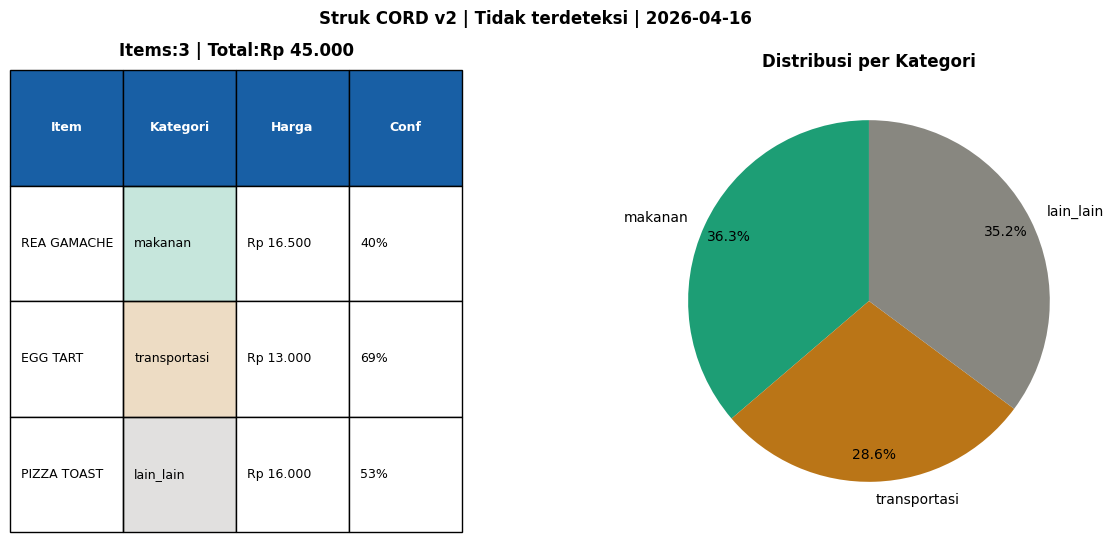

Tersimpan: pipeline_result.png


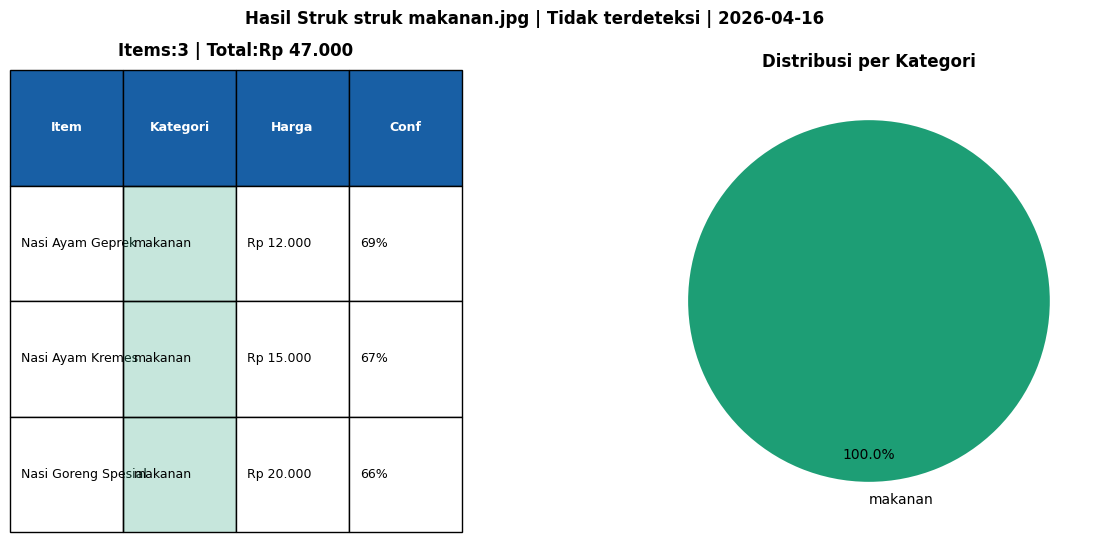

Tersimpan: pipeline_result.png


In [41]:
def visualisasi_hasil(result, title="Hasil Pipeline Head 1"):
    if not result or result.get("status")!="success" or not result["items"]:
        print("Tidak ada hasil."); return
    items = result["items"]
    fig = plt.figure(figsize=(14,6)); gs = fig.add_gridspec(1,2,wspace=0.4)
    ax1 = fig.add_subplot(gs[0]); ax2 = fig.add_subplot(gs[1])
    ax1.axis('off')
    tbl = ax1.table(
        cellText=[[it['item_name'][:22],it['kategori'],
                   f"Rp {it['harga']:,}".replace(',','.'),f"{it['confidence']:.0f}%"]
                  for it in items],
        colLabels=['Item','Kategori','Harga','Conf'],
        cellLoc='left', loc='center', bbox=[0,0,1,1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(9)
    for j in range(4):
        tbl[0,j].set_facecolor("#185FA5"); tbl[0,j].set_text_props(color='white',fontweight='bold')
    for i, it in enumerate(items):
        tbl[i+1,1].set_facecolor(CAT_COLORS.get(it['kategori'],'#888780')+'40')
    ax1.set_title(f"Items:{len(items)} | Total:Rp {result['total']:,}".replace(',','.'),
                  fontweight='bold', pad=10)
    summary = result.get("summary_per_kategori",{})
    if summary:
        labels = list(summary.keys()); values = [summary[k]["total"] for k in labels]
        colors = [CAT_COLORS.get(k,'#888780') for k in labels]
        ax2.pie(values,labels=labels,colors=colors,autopct='%1.1f%%',startangle=90,pctdistance=0.85)
        ax2.set_title('Distribusi per Kategori', fontweight='bold')
    fig.suptitle(f"{title} | {result['store_name']} | {result['date']}",fontsize=12,fontweight='bold')
    plt.savefig('pipeline_result.png', dpi=120, bbox_inches='tight')
    plt.show(); print("Tersimpan: pipeline_result.png")


if results_all: visualisasi_hasil(results_all[0], title="Struk CORD v2")
visualisasi_hasil(result, title=f"Hasil Struk {fname}")

---
## Ringkasan

| Bagian | Konten | Cell |
|--------|--------|------|
| A - Dataset | 9.600 sampel sintetis, 8 kategori mahasiswa | 3-4 |
| B - Training | BiLSTM + Attention + GradientTape + FocalLoss | 5-9 |
| C - Donut | Load model fine-tuned CORD v2 | 10 |
| D - Parser | parse_donut_output v6 (semua format struk) | 11 |
| E - Pipeline | End-to-end + test CORD v2 + visualisasi | 12-15 |

Output JSON siap untuk `POST /api/scan-struk` di FastAPI.
